<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_10_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SUPPORT VECTOR MACHINE (SVM) – Drug Response Classification
Dataset: Pharma_Industry.csv

#Introduction to the Assignment

The pharmaceutical industry faces significant challenges in developing effective drugs due to variability in patient responses. Clinical trials are both time-consuming and expensive, and not all patients respond positively to a given treatment. This variability arises from differences in genetics, metabolism, lifestyle, and pre-existing medical conditions.

To address these challenges, machine learning techniques are increasingly being used to predict drug efficacy at an early stage. This assignment focuses on applying a powerful classification algorithm, Support Vector Machine (SVM), to analyze and predict drug response using the dataset Pharma_Industry.csv.

##Problem Statement

The primary objective of this assignment is to build a predictive model that classifies patient drug responses into two categories:

0 (No Response): The drug is ineffective for the patient
1 (Positive Response): The drug is effective for the patient

By analyzing patient-related features—such as biomarkers, medical conditions, and other clinical attributes—the model aims to determine whether a patient is likely to benefit from a specific drug.

##1.Exploratory Data Analysis (EDA):

Understanding the dataset through
statistical summaries and visualizations to identify patterns, distributions, and feature correlations to discern relationships within the data.

###1. Fundamental fundamental data exploration through statistical summaries

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Pharma_Industry.csv")

# View data
display(df.head())

# Dataset info
print(df.info())

# Statistical summary
display(df.describe())

# Check missing values
print(df.isnull().sum())

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64


Data set contains 500 rows, 6 columns.

5 columns are float type and one is integer type.

`Drug Dosage (mg)`: This represents the dosage of the drug administered in milligrams, a continuous numerical variable.

`Systolic Blood Pressure (mmHg)`: This is a physiological measurement of systolic blood pressure in millimeters of mercury, a continuous numerical variable.

`Heart Rate (BPM)`: This indicates the patient's heart rate in beats per minute, a continuous numerical variable.

`Liver Toxicity Index (U/L)`: This measures the liver toxicity level in units per liter, a continuous numerical variable.

`Blood Glucose Level (mg/dL)`: This represents the blood glucose level in milligrams per deciliter, a continuous numerical variable.

`Drug Response`: This is the target variable, an integer (0 or 1) indicating whether the patient showed no response (0) or a positive response (1) to the drug. This is a categorical variable, specifically a binary classification target.

No null values in any column



The df.describe() output provides a statistical summary for each numerical column in your dataset. Here's a brief explanation:

Count: The number of non-null observations in each column. For all columns, it's 500, meaning there are no missing values.

Mean: The average value of the data in each column. For instance, the average 'Drug Dosage (mg)' is approximately -0.038.

Std (Standard Deviation): Measures the amount of variation or dispersion of a set of values. A higher standard deviation indicates that the data points are spread out over a wider range of values. Most columns have a standard deviation around 1, suggesting a moderate spread.

Min: The smallest value in each column.
25% (Q1): The first quartile, meaning 25% of the data falls below this value.

50% (Median): The median or second quartile, indicating that 50% of the data falls below this value. It's the middle value when the data is ordered.

75% (Q3): The third quartile, meaning 75% of the data falls below this value.

Max: The largest value in each column.
From this output, we can see that most of the numerical features seem to be standardized or scaled, as their means are close to 0 and standard deviations are close to 1, with values ranging from approximately -3 to +3.

The Drug Response column, with a mean of 0.52, indicates that slightly more than half of the patients (52%) showed a positive response (1), and its min/max values confirm it's a binary variable (0 or 1).



###2.histograms, box plots, or density plots to understand feature distributions

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

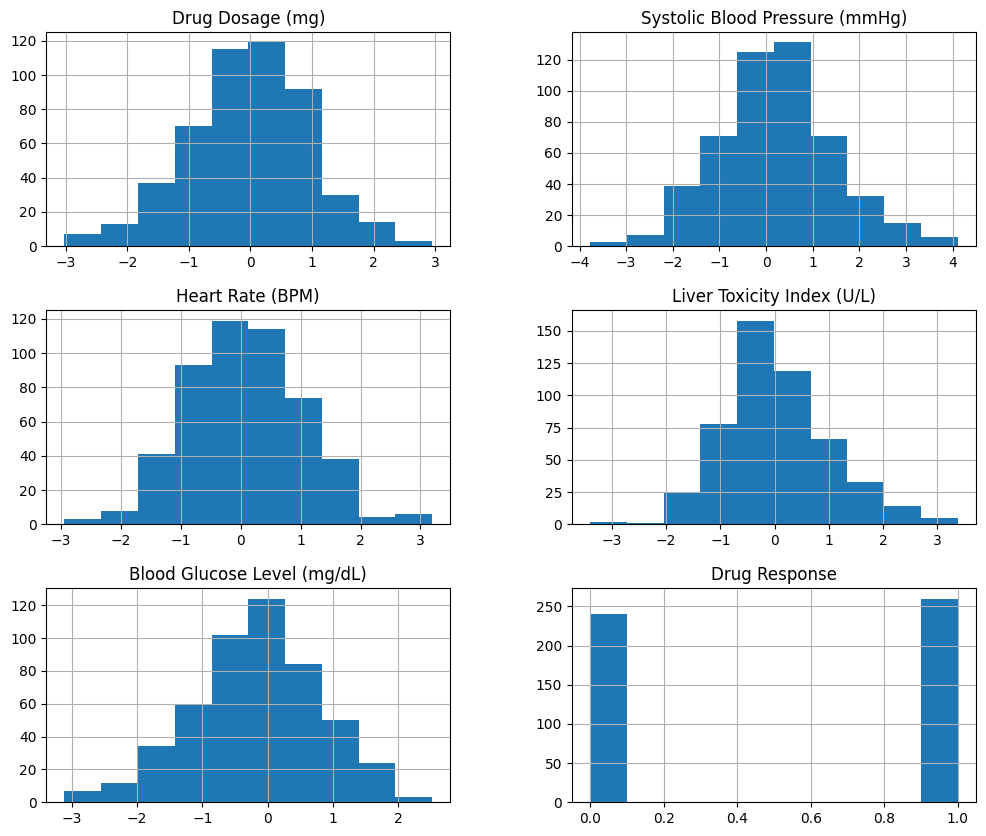

In [ ]:
# Histograms
df.hist(figsize=(12,10))
plt.show()

The histograms show the distribution of each feature. Most features ('Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)') appear to have a roughly normal or slightly skewed distribution, centered around zero, which is consistent with the df.describe() output suggesting they are standardized or scaled. The 'Drug Response' column, being a binary variable (0 or 1), shows two distinct bars at 0 and 1, indicating the counts for 'No Response' and 'Positive Response' respectively. It appears there are slightly more instances of 'Positive Response' (1) than 'No Response' (0).



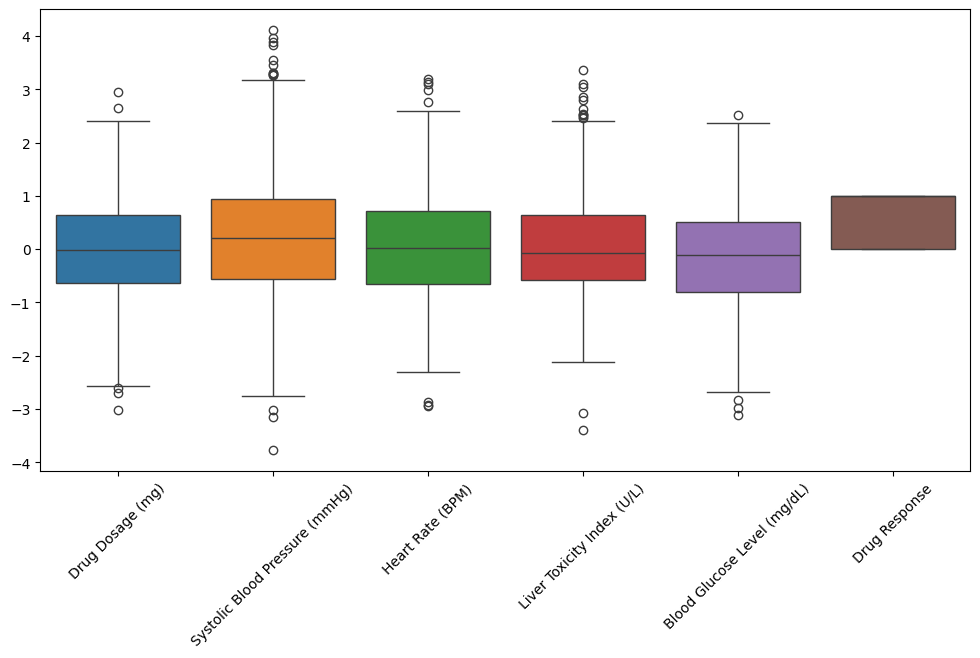

In [ ]:
# Boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

The box plots display the distribution of each feature, highlighting the median, quartiles, and potential outliers.

###Central Tendency and Spread:
 For most numerical features (Drug Dosage, Systolic Blood Pressure, Heart Rate, Liver Toxicity Index, Blood Glucose Level), the box plots show that their medians are close to zero, and the interquartile ranges (the boxes themselves) are relatively narrow, suggesting that a majority of the data points are clustered around the mean. This further supports the observation that these features are standardized or scaled.
###Symmetry:
The boxes appear relatively symmetrical with the median line close to the center of the box, indicating a fairly symmetrical distribution for most features.

###Outliers:
 Some features, particularly 'Systolic Blood Pressure (mmHg)' and 'Liver Toxicity Index (U/L)', show several individual points plotted beyond the whiskers. These represent potential outliers, which are data points significantly different from other observations.

###Drug Response:
 The 'Drug Response' column, being a binary variable, shows two distinct lines at 0 and 1, confirming its categorical nature rather than a continuous distribution. The box and whiskers are not meaningful for this type of variable.


###3. 3.Feature correlations to discern relationships within the data.

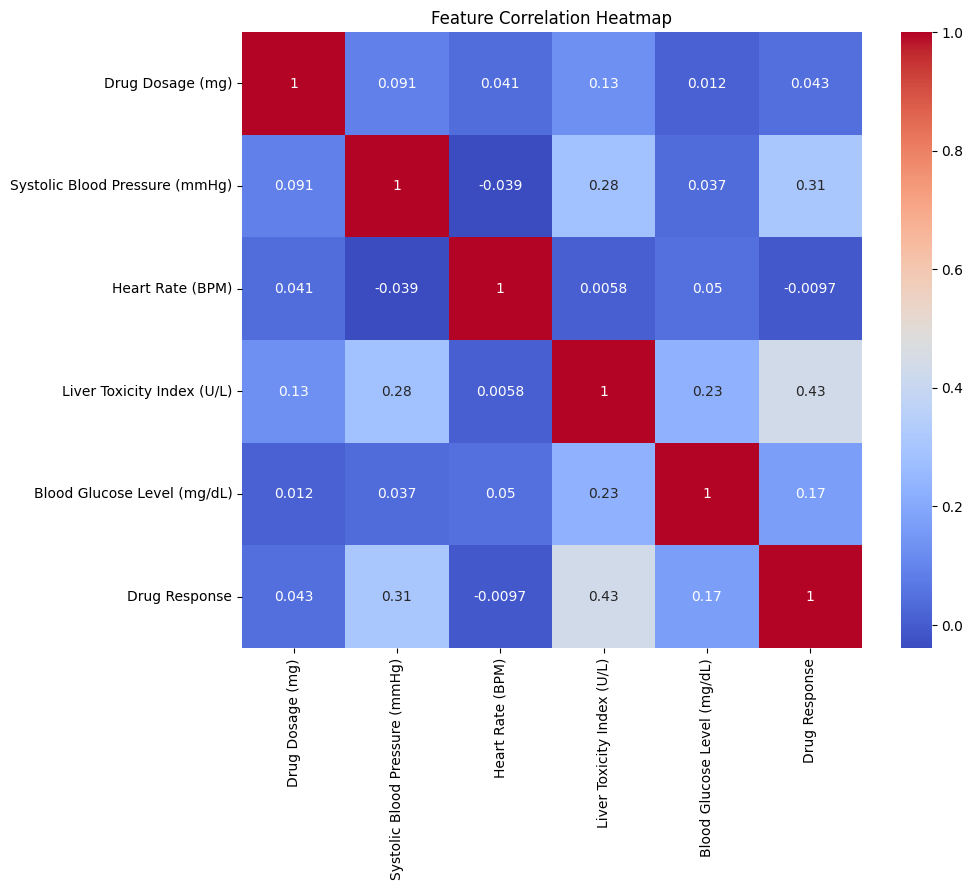

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

##The heatmap visualizes the correlation matrix of the features.

###Inter-Feature Correlations:
 Most of the features appear to have very low correlations with each other (values close to 0), indicating that they are largely independent. This is generally a good characteristic for machine learning models as it avoids multicollinearity issues.

###Correlation with Drug Response:
The 'Drug Response' column shows relatively low correlations with all other features. This suggests that no single feature strongly predicts drug response in a linear fashion. While this doesn't rule out non-linear relationships, it implies that a simple linear model might struggle, and an SVM could potentially find more complex decision boundaries.


##2.Data Preprocessing:
Preparing the dataset by handling categorical variables, splitting into training and testing sets, and ensuring data is suitable for modeling.


###1 Encoding Categorical Variables
The `Drug Response` column is a binary variable, already represented numerically as 0s and 1s, which signifies its categorical nature (specifically, a binary classification target).
All other columns (Drug Dosage (mg), Systolic Blood Pressure (mmHg), Heart Rate (BPM), Liver Toxicity Index (U/L), and Blood Glucose Level (mg/dL)) are continuous numerical variables. This means you won't need to perform any additional encoding steps for these columns before using them in your SVM model.*

### 2.	Split the dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print("\n--- Scaled X_train Statistics ---")
print("Min values per feature:", X_train.min(axis=0))
print("Max values per feature:", X_train.max(axis=0))
print("Mean values per feature:", X_train.mean(axis=0))
print("Std Dev per feature:", X_train.std(axis=0))

print("\n--- Scaled X_test Statistics ---")
print("Min values per feature:", X_test.min(axis=0))
print("Max values per feature:", X_test.max(axis=0))
print("Mean values per feature:", X_test.mean(axis=0))
print("Std Dev per feature:", X_test.std(axis=0))


--- Scaled X_train Statistics ---
Min values per feature: [-3.01989374 -3.15874065 -3.0799406  -3.39089965 -2.96304647]
Max values per feature: [3.00844759 3.00774759 3.18712882 3.27747839 2.71626873]
Mean values per feature: [ 8.88178420e-18  0.00000000e+00 -1.55431223e-17  2.22044605e-17
 -3.33066907e-17]
Std Dev per feature: [1. 1. 1. 1. 1.]

--- Scaled X_test Statistics ---
Min values per feature: [-2.35674287 -1.90753687 -2.12301897 -1.98284689 -2.82759047]
Max values per feature: [2.11300516 3.127662   2.33983495 2.4643732  2.53306837]
Mean values per feature: [-0.04150361  0.1057774  -0.05638292  0.05309697  0.01037656]
Std Dev per feature: [0.94145431 0.96273464 0.95878961 0.8355536  0.95753601]


Inference

Scaling is essential for SVM since it is distance-based.

##3.Visualization:
Using plots to explore feature interactions and class distributions.

### 1.Scatter plots
sns.pairplot(df) will generate a grid of scatter plots for every pairwise combination of numerical features in your DataFrame df. It also includes histograms or KDE plots on the diagonal to show the distribution of each individual feature.

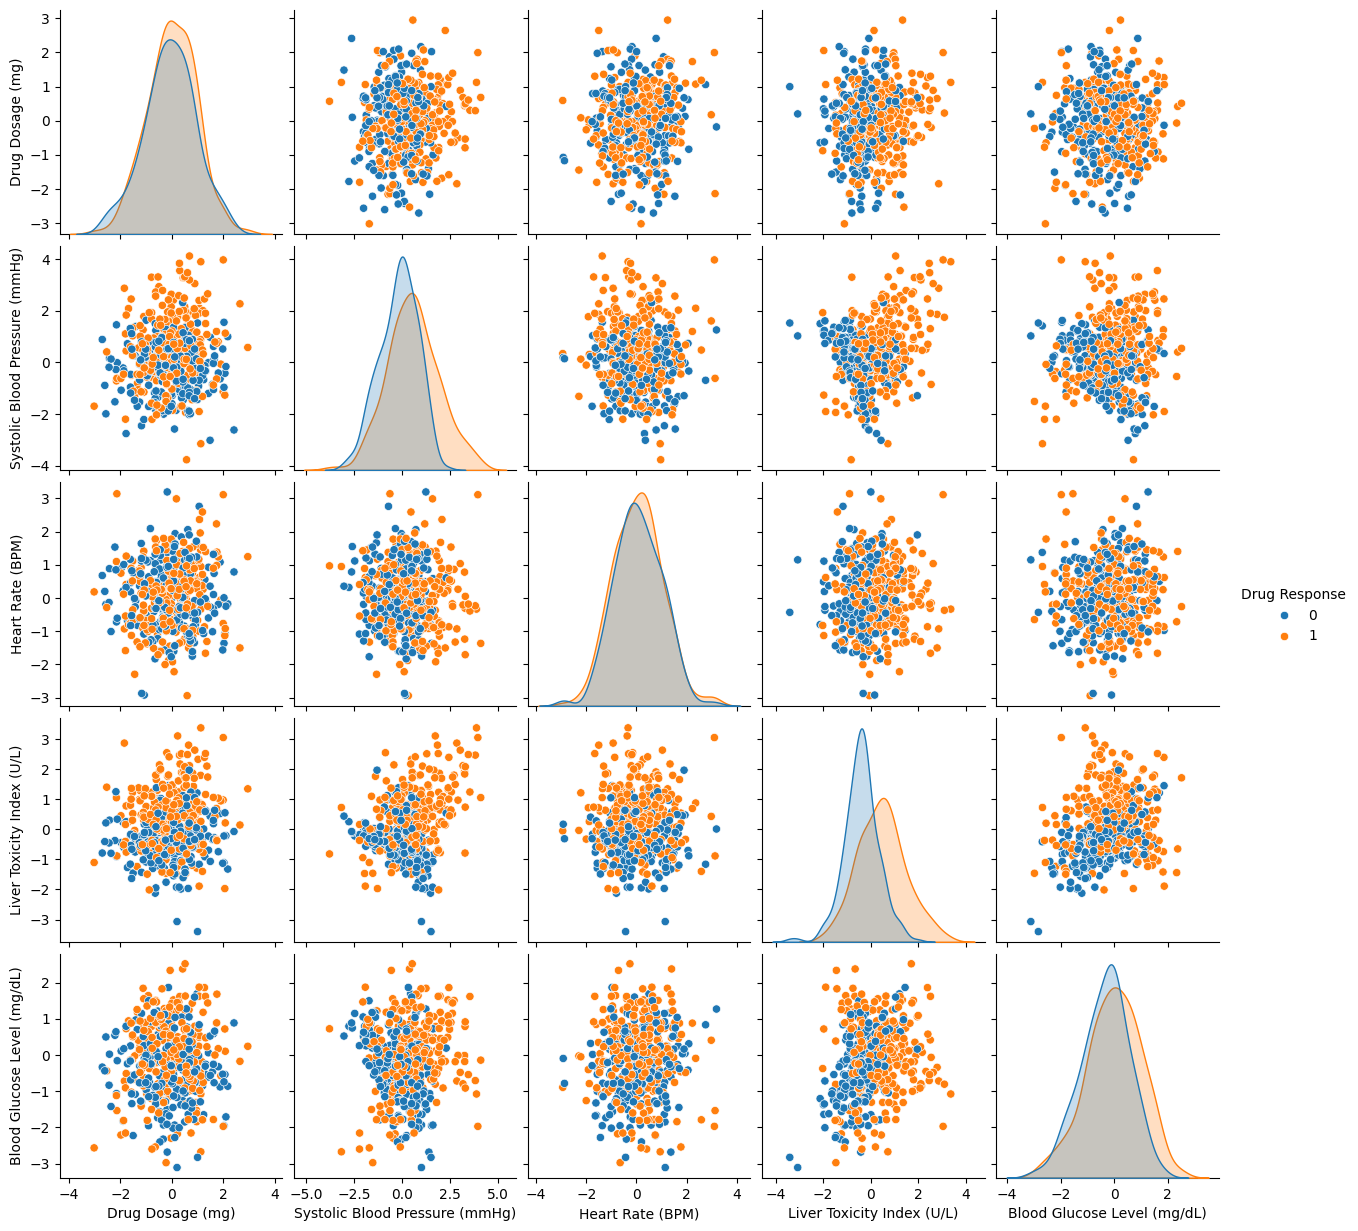

In [ ]:
sns.pairplot(df, hue='Drug Response')
plt.show()

###The `pairplot` provides a comprehensive overview of the relationships between all numerical features in the dataset.

*   **Off-diagonal plots:** These are scatter plots showing the relationship between two different features. The `hue='Drug Response'` parameter colors the points based on the 'Drug Response' (0 for no response, 1 for positive response), allowing us to visually inspect how the two classes separate or overlap across different feature combinations.

*   **Diagonal plots:** These show the univariate distribution of each feature, with separate density estimates (KDEs) for each 'Drug Response' class. This helps in understanding the distribution of each feature and how it varies between the two response groups.

####From these plots, we can observe that while there is some visual separation between the 'No Response' and 'Positive Response' classes in various feature pairs, there is also significant overlap. This suggests that the classes are not easily linearly separable based on individual feature pairs, indicating that a more complex model like SVM, which can find non-linear decision boundaries, would be beneficial. The overlapping regions highlight where classification might be more challenging due to similar feature values for both response types.


##2 class distributions to gauge dataset balance or imbalance

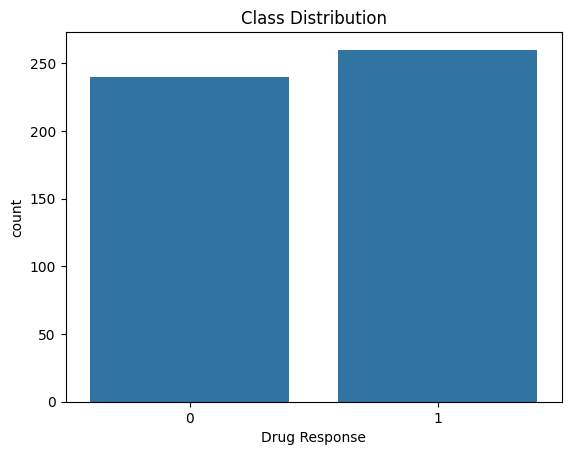

In [ ]:
sns.countplot(x='Drug Response', data=df)
plt.title("Class Distribution")
plt.show()

The `countplot` visually represents the distribution of the `Drug Response` variable. Each bar corresponds to a response category (0 for 'No Response' and 1 for 'Positive Response'), and the height of the bar indicates the number of patients in that category. This plot clearly shows the balance or imbalance between the two classes. In this case, there appear to be slightly more patients with a 'Positive Response' (1) than 'No Response' (0), indicating a relatively balanced, though not perfectly equal, dataset for the target variable.

## 4: SVM Implementation
### 1 Train SVM Model

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='linear')

model.fit(X_train, y_train)

SVC(kernel='linear')

###2 Predictions

In [ ]:
y_pred = model.predict(X_test)

###3 Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.78

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100


Confusion Matrix:
 [[36  8]
 [14 42]]


Inference

Accuracy shows overall performance.
Precision & Recall indicate class-wise performance.
Confusion matrix helps identify misclassifications.

##\ 5: Visualization of SVM Results

1.	Visualize classification results on the testing data.

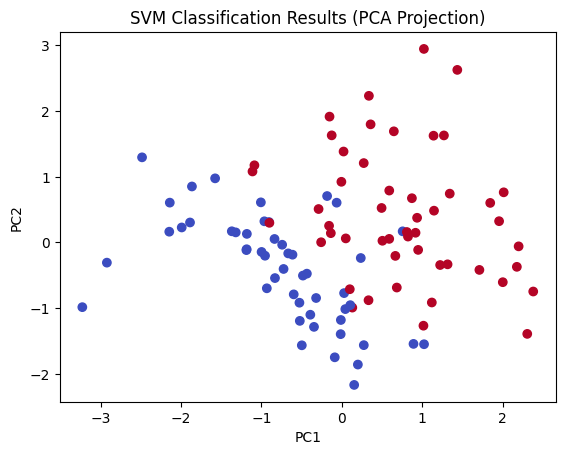

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=y_pred, cmap='coolwarm')
plt.title("SVM Classification Results (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

PCA reduces the dimensionality of the data to 2 by transforming the original features into two new features. These new features are linear combinations of the original ones. This transformation helps make the data easier to visualize in a 2D plot, as shown in the scatter plot.

The scatter plot, derived from PCA of the test data and colored by the SVM's predictions, visualizes how well the model separates the two classes (0 and 1). Observing the plot, we can generally see two clusters corresponding to the predicted 'No Response' and 'Positive Response' classes. However, there's likely some intermingling or overlap of points between these clusters, indicating instances where the SVM made incorrect classifications, especially in regions where the classes are not clearly separable.

The previous SVM model used fixed hyperparameters, which may not capture the optimal decision boundary, especially in cases where the data shows overlap and nonlinear patterns. To address this limitation, GridSearchCV is used to systematically tune key parameters such as C, kernel, and gamma using cross-validation. This approach helps identify the best-performing configuration, improving the model’s ability to generalize and better separate the classes.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


The above out put  tells that:

RBF kernel performed best → Data is not linearly separable, and a nonlinear boundary is needed

C = 1 → a balanced model (not too strict, not too flexible)

gamma = 'scale' → a well-balanced influence of data points, avoiding overfitting

Now that we have the best parameters, we should:

Use the best model to make predictions on test data

##Train Best Model

In [ ]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))

Optimized Accuracy: 0.84


Tuned SVM (with RBF kernel, C=1, gamma='scale') correctly classifies 84% of the test data.
This indicates a good improvement over a basic or untuned model, especially given the overlap observed earlier.

It also shows that a nonlinear boundary (RBF) is better suited for the data than a simple linear separation.

 In short: The tuning step successfully found a model that generalizes reasonably well to unseen data.

###Final Improved scatter plot, visualizing the results of optimized SVM model

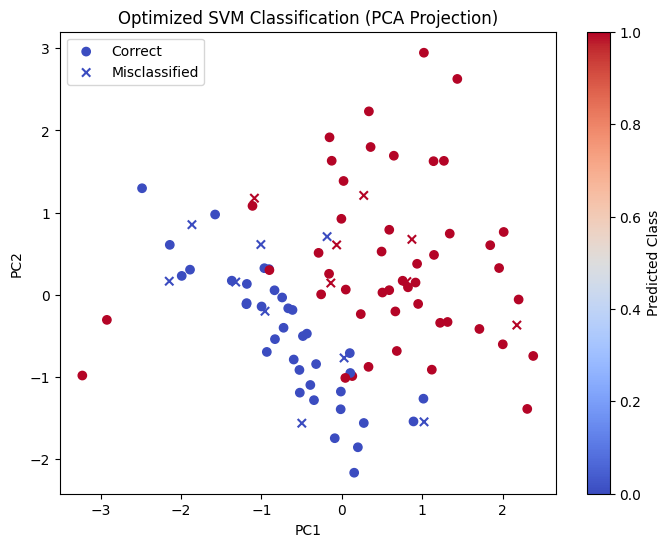

In [ ]:
plt.figure(figsize=(8,6))

#y_pred_best = best_model.predict(X_test)
correct = y_pred_best == y_test

plt.scatter(X_test_pca[correct, 0], X_test_pca[correct, 1],
            c=y_pred_best[correct], cmap='coolwarm', marker='o', label='Correct')

plt.scatter(X_test_pca[~correct, 0], X_test_pca[~correct, 1],
            c=y_pred_best[~correct], cmap='coolwarm', marker='x', label='Misclassified')

plt.colorbar(label='Predicted Class')
plt.legend()

plt.title("Optimized SVM Classification (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

#7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).


In [ ]:
kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{k} Kernel Accuracy:", accuracy_score(y_test, y_pred))

linear Kernel Accuracy: 0.78
rbf Kernel Accuracy: 0.84
poly Kernel Accuracy: 0.71


####The comparison shows that the RBF kernel is most suitable, as it captures the nonlinear relationships in the data better than linear or polynomial kernels.

###2. Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results:

From the EDA and PCA visualization, the dataset shows partial overlap between classes, indicating that it is not perfectly linearly separable. A key strength of SVM is its ability to handle such cases using kernels like RBF, which can model nonlinear decision boundaries effectively, as reflected in the improved accuracy. However, the overlap also highlights a limitation: SVM may still misclassify points in regions where classes are highly intermixed. Additionally, SVM is sensitive to parameter tuning and feature scaling, and without proper tuning (as seen initially), its performance may be suboptimal.

###3. Discuss practical implications of SVM in real-world classification tasks:
In real-world applications, SVM is a powerful and versatile classifier, especially for problems with complex but structured decision boundaries, such as medical diagnosis, text classification, and image recognition. Its ability to generalize well and avoid overfitting (with proper tuning) makes it reliable for many tasks. However, it requires careful selection of kernels and hyperparameters, and can be computationally expensive for large datasets. Therefore, while SVM is highly effective for moderate-sized datasets with clear patterns, practitioners must balance accuracy, interpretability, and computational cost when applying it in practical scenarios.

##Overall Conclusion

The SVM model proved effective for this dataset, especially after tuning, with the RBF kernel providing the best performance due to its ability to handle nonlinear class boundaries. While some overlap in the data limits perfect classification, the optimized model achieves good accuracy and generalization. Overall, SVM is a strong choice for this problem, provided that proper preprocessing and parameter tuning are applied.